# <img style="float: left; padding-right: 20px; width: 200px" src="https://github.com/ymotomy/ymotomy.github.io/blob/main/imagenes/UC.png?raw=true">  IMT2118 - Ciencia de Datos Geoespaciales
**Pontificia Universidad Católica de Chile**<br>
**Semestre 2025-1**<br>
**Estudiantes:** Christian Camilo | Tomás Romero <br>
---

<hr>
<h1 style="text-align:center;"> Recomendador de Localizaciones para Observatorios en Chile usando Imágenes Satelitales y Datos Raster/Vectoriales

Chile se ha consolidado como uno de los destinos más privilegiados del mundo para la observación astronómica, gracias a sus cielos despejados, baja humedad atmosférica y reducida contaminación lumínica en vastas zonas del norte del país. Sin embargo, con el crecimiento urbano, el cambio climático y el avance de la infraestructura, resulta cada vez más necesario identificar nuevos sitios potenciales que maximicen las condiciones óptimas para la instalación de observatorios astronómicos.

Este proyecto propone el desarrollo de un sistema de recomendación basado en análisis multicriterio espacial para predecir zonas favorables para la construcción de observatorios en Chile. Para ello, se utilizarán imágenes satelitales y datos geoespaciales provenientes de diversas fuentes, tales como sensores MODIS, Sentinel-5P, Landsat y DMSP-OLS, combinando información sobre contaminación lumínica, cobertura nubosa, altitud, calidad del aire, uso de suelo y proximidad a centros urbanos.

A través del uso de herramientas como Google Earth Engine y Python, se desarrollará un flujo automatizado de procesamiento y análisis que permita integrar tanto datos raster como vectoriales. El resultado será una visualización dinámica e interactiva de los sitios más idóneos, que considere tanto criterios astronómicos como restricciones territoriales.

Este estudio busca no solo aplicar técnicas avanzadas de ciencia de datos geoespaciales, sino también contribuir a la planificación estratégica de infraestructura astronómica en Chile, promoviendo el uso sustentable del territorio en armonía con el desarrollo científico.
<hr>

## Librerías

In [437]:
#Primero importamos algunas librerias
import os
from glob import glob
import geemap,ee
import numpy as np
import pandas as pd
import geopandas as gpd
import seaborn as sns


import matplotlib.pyplot as plt
from shapely.geometry import MultiPolygon
from shapely.geometry import Polygon, Point
from shapely.ops import nearest_points

from sklearn.preprocessing import MinMaxScaler
from scipy.spatial.distance import cdist

import libpysal
from libpysal.weights import Queen
from esda.moran import Moran
import matplotlib.pyplot as plt
from esda.moran import Moran_Local

from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.neighbors import BallTree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import silhouette_score


#Ignormaos los warnings
import warnings
warnings.filterwarnings("ignore")

#Sin ilmite de columnas
pd.set_option('display.max_columns', None)

In [438]:
ee.Authenticate()
ee.Initialize(project='ee-ccamz2')
#ee.Initialize(project='ee-tomasromero')

In [439]:
# Seleccionamos rango de fechas
startDate= '2024-01-01'
endDate = '2025-01-01'

## Observatorios

In [440]:
obs = gpd.read_file("Datos/observatorios/observatorios.shp").to_crs(epsg=4326)

#nos quedatos con los tipo radio, opticos, infrarrojo y los categorizamos
obs = obs[obs['Tipo'].isin(['Radio', 'Óptico', 'Infrarrojo', 'Óptico/Infrarrojo'])].reset_index(drop=True)
obs['Radio'] = obs['Tipo'].str.contains('Radio')
obs['Optico'] = obs['Tipo'].str.contains('Óptico')
obs['Infrarrojo'] = obs['Tipo'].str.contains('Infrarrojo')
obs.drop(columns=['Tipo', 'Nombre', 'Estado'], inplace=True)

print(obs.shape)
obs.head()

(71, 8)


,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo
0,5000,"Llano de Chajnantor, Antofagasta",2003,41001.06121734071,POINT (-67.7546 -23.0221),True,False,False
1,5100,"Llano de Chajnantor, Antofagasta",2003,113.09733552923257,POINT (-67.7533 -23.0056),True,False,False
2,5190,"Cerro Toco, Antofagasta",2007,28.274333882308134,POINT (-67.7875 -22.9583),True,False,False
3,2635,"Cerro Paranal, Antofagasta",1991,211.23836840423655,POINT (-70.4042 -24.6272),False,True,True
4,3046,"Cerro Armazones, Antofagasta",2014,1194.690595328151,POINT (-70.19 -24.5895),False,True,True


In [441]:
m = gpd.read_file("Datos/ne_110m_land/ne_110m_land.shp").to_crs(epsg=4326)

(-198.0, 198.00000000000014, -98.68225650000004, 92.32738650000003)

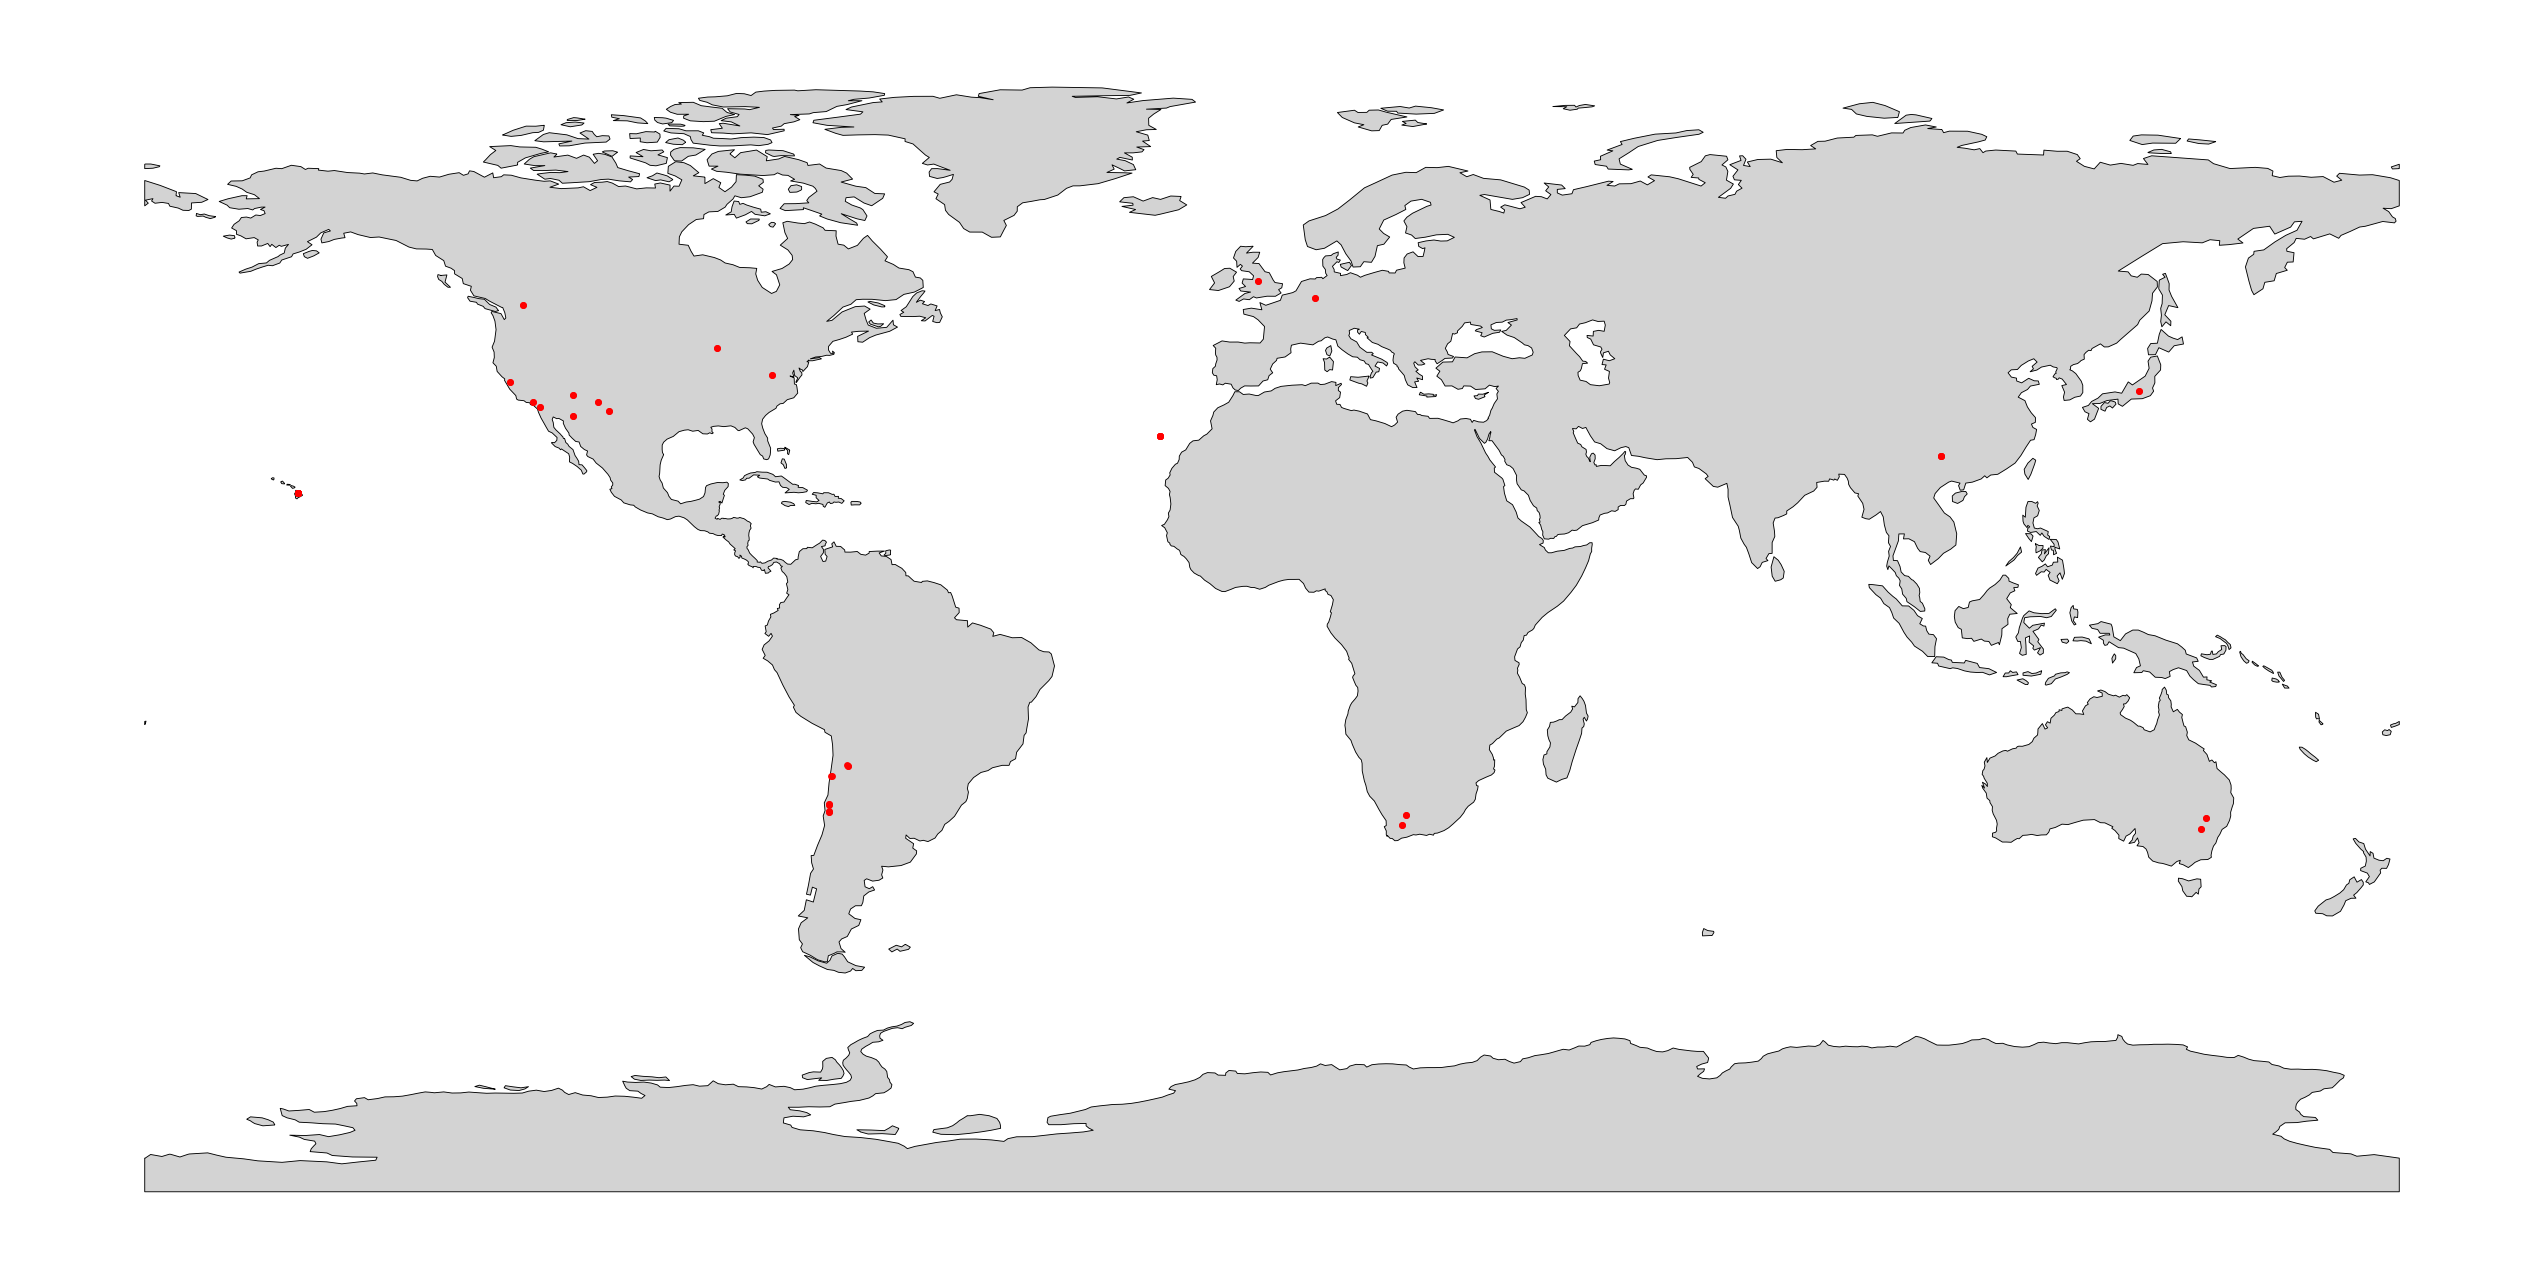

In [442]:
fig, ax = plt.subplots(figsize=(10, 10), dpi=320)
m.plot(ax=ax, edgecolor='black', facecolor='lightgray', linewidth=0.2)
obs.plot(ax=ax, color='red', markersize=0.3, label='Observatorios')
ax.axis('off')

## Mapa de Chile

In [443]:
chile = gpd.read_file('Datos/Comunas/Comunas.shp').to_crs(epsg=4326).to_crs(epsg=32719)
chile = chile[chile['codregion'].isin([1, 2, 3, 4])]

#Quitamos isla de pascua y juan fernandez
chile = chile[~chile['Comuna'].isin(['Isla de Pascua', 'Juan Fernández'])]

In [444]:
#Unimos todas las comunas en una figura

def keep_only_mainland(geom):
    if geom.geom_type == 'Polygon':
        return geom
    elif geom.geom_type == 'MultiPolygon':
        return max(geom.geoms, key=lambda g: g.area)
    return geom

chile['geometry'] = chile['geometry'].buffer(0)

chile['geometry'] = chile['geometry'].apply(keep_only_mainland)
chile = gpd.GeoDataFrame(geometry=[chile.unary_union], crs=chile.crs)

In [445]:
# Eliminar huecos interiores

def remove_holes(geom):
    if geom.geom_type == 'Polygon':
        return Polygon(geom.exterior)
    elif geom.geom_type == 'MultiPolygon':
        return MultiPolygon([Polygon(g.exterior) for g in geom.geoms])
    return geom

chile['geometry'] = chile['geometry'].apply(remove_holes)

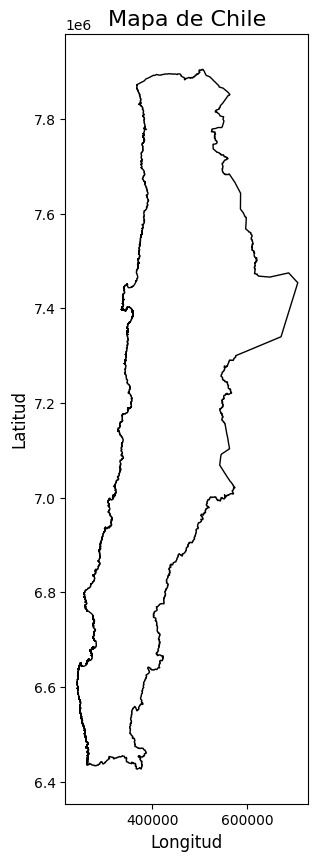

In [446]:
chile.plot(color='white', edgecolor='black', figsize=(10, 10))
# Añadir título y etiquetas
plt.title('Mapa de Chile', fontsize=16)
plt.xlabel('Longitud', fontsize=12)
plt.ylabel('Latitud', fontsize=12)
plt.show()

### Creamos los hexagonos para Chile

In [447]:
# # 6. Crear hexágonos
# def create_hex_grid(gdf, hex_radius):
#     bounds = gdf.total_bounds
#     xmin, ymin, xmax, ymax = bounds
#     dx = 3/2 * hex_radius
#     dy = np.sqrt(3) * hex_radius
#     cols = int((xmax - xmin) / dx) + 2
#     rows = int((ymax - ymin) / dy) + 2

#     hexes = []
#     for row in range(rows):
#         for col in range(cols):
#             x = xmin + col * dx
#             y = ymin + row * dy
#             if col % 2 == 1:
#                 y += dy / 2
#             hex = Polygon([
#                 (x + hex_radius * np.cos(np.radians(angle)),
#                  y + hex_radius * np.sin(np.radians(angle)))
#                 for angle in range(0, 360, 60)
#             ])
#             hexes.append(hex)

#     return gpd.GeoDataFrame(geometry=hexes, crs=gdf.crs)

In [448]:
# hexagonos = create_hex_grid(chile, hex_radius=5000)
# hexagonos = gpd.overlay(hexagonos, chile, how='intersection').to_crs(epsg=4326)
# hexagonos.head(1)

In [449]:
# hexagonos.to_file("Datos/Hexagonos/ch/hexagonos_chile.shp", driver='ESRI Shapefile')
hexagonos = gpd.read_file("Datos/Hexagonos/ch/hexagonos_chile.shp").to_crs(epsg=4326)

### Obtenemos los hexagonos para los observatorios fuera de Chile

In [450]:
#obtenemos los id de los hexagonos donde estan los observatorios
obs_chile = obs[obs.geometry.within(hexagonos.unary_union)]
obs_chile = obs_chile.reset_index(drop=True)
obs_chile.head(1)

,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo
0,5000,"Llano de Chajnantor, Antofagasta",2003,41001.06121734071,POINT (-67.7546 -23.0221),True,False,False


In [451]:
# a obs le quitamos los observatorios que estan en obs_chile
obs = obs[~obs.geometry.within(hexagonos.unary_union)]
obs.head(1)

,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo
11,2124,Nuevo México-USA,1980,1256.6370614359173,POINT (-107.6184 34.0788),True,False,False


In [452]:
# #Le pedimos a chatgpr que nos creara un hexagono al rededor de los observatorios fuera de chile
# # y como no podemos reproyectar todo a 32719, transformamos cada locacion a su respectivo UTM
# def get_utm_epsg(lat, lon):
#     zone_number = int((lon + 180) / 6) + 1
#     if lat >= 0:
#         return 32600 + zone_number  # Norte
#     else:
#         return 32700 + zone_number  # Sur


In [453]:
# def create_hexagon(center, radius_m=5000):
#     angles = np.linspace(0, 360, 6, endpoint=False)
#     coords = [
#         (
#             center.x + radius_m * np.cos(np.radians(a)),
#             center.y + radius_m * np.sin(np.radians(a))
#         )
#         for a in angles
#     ]
#     return Polygon(coords)

In [454]:
# hexes = []
# attributes = []

# for _, row in obs.iterrows():
#     lon, lat = row.geometry.x, row.geometry.y
#     epsg = get_utm_epsg(lat, lon)
    
#     # Crear GeoDataFrame con un solo punto y proyectarlo
#     gdf_point = gpd.GeoDataFrame(geometry=[Point(lon, lat)], crs='EPSG:4326').to_crs(epsg=epsg)
#     projected_point = gdf_point.geometry.iloc[0]

#     # Crear hexágono en proyección métrica
#     angles = np.linspace(0, 360, 6, endpoint=False)
#     coords = [
#         (
#             projected_point.x + 5000 * np.cos(np.radians(a)),
#             projected_point.y + 5000 * np.sin(np.radians(a))
#         )
#         for a in angles
#     ]
#     hex_local = Polygon(coords)

#     # Reproyectar hexágono a EPSG:4326
#     hex_global = gpd.GeoSeries([hex_local], crs=f"EPSG:{epsg}").to_crs(epsg=4326).iloc[0]

#     hexes.append(hex_global)
#     attributes.append(row.drop("geometry"))

# # Crear GeoDataFrame final con hexágonos y atributos originales
# hex_ext = gpd.GeoDataFrame(attributes, geometry=hexes, crs="EPSG:4326")
# hex_ext.to_file("Datos/Hexagonos/ext/hexagonos_ext.shp", driver='ESRI Shapefile')
# hex_ext = gpd.read_file("Datos/Hexagonos/ext/hexagonos_ext.shp").to_crs(epsg=4326)

In [455]:
# #Juntamos los hexagonos de los observatorios con los hexagonos de la grilla
# hexagonos = pd.concat([hexagonos, hex_ext], ignore_index=True)
# #creamos un id para los hexagonos
# hexagonos['id'] = range(1, len(hexagonos) + 1)
# #pasamos a geopandas
# hexagonos = gpd.GeoDataFrame(hexagonos, geometry='geometry', crs="EPSG:4326").to_crs(epsg=4326)
# hexagonos = hexagonos[["geometry", "id"]]
# hexagonos.head(1)

### Guardamos los hexagonos

In [456]:
# path = "Datos/Hexagonos"
# os.makedirs(path, exist_ok=True)
# hexagonos.to_file(f"{path}/hexagonos.shp", driver='ESRI Shapefile')

### Lo volvemos a cargar

In [457]:
hexagonos = gpd.read_file("Datos/Hexagonos/hexagonos.shp").to_crs(epsg=4326)
chile = chile.to_crs(epsg=4326)

In [458]:
obs = pd.concat([obs, obs_chile], ignore_index=True) ; obs_chile = None
obs = obs.reset_index(drop=True)
obs = gpd.GeoDataFrame(obs, geometry='geometry', crs="EPSG:4326")
print(obs.shape)
obs.head(1)

(71, 8)


,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo
0,2124,Nuevo México-USA,1980,1256.6370614359173,POINT (-107.6184 34.0788),True,False,False


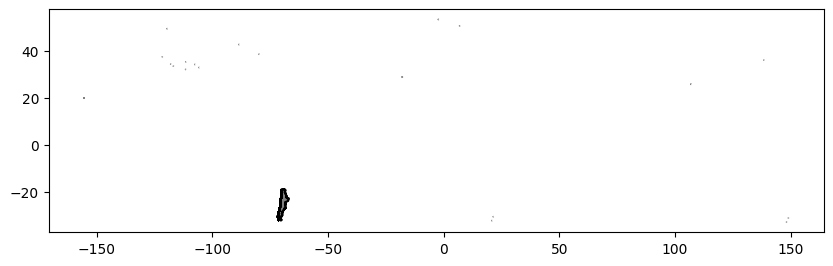

In [459]:
fig, ax = plt.subplots(figsize=(10, 10))
chile.boundary.plot(ax=ax, color='black')
hexagonos.plot(ax=ax, edgecolor='gray', facecolor='none')
plt.show()

In [460]:
# # a cada observatorio le asignamos el hexagono al que pertenece
obs['hex_id'] = obs.geometry.apply(lambda x: hexagonos[hexagonos.contains(x)].id.values[0] if not hexagonos[hexagonos.contains(x)].empty else None)
obs.head(1)

,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo,hex_id
0,2124,Nuevo México-USA,1980,1256.6370614359173,POINT (-107.6184 34.0788),True,False,False,4690


### Subimos el archivo como asset a Google Earth Engine (manualmente), y lo leemos

In [461]:
asset_path = "projects/ee-tomasromero/assets/hexagonos"
hex_fc = ee.FeatureCollection(asset_path)

## Obtenemos la informacion de los Satelites

In [462]:
tasks = []

In [463]:
def export_satellite_band_to_hexagons(asset_path, image, band_name, output, scale=500, collection=True):
    if collection:
        image = image.select(band_name).mean()
    
    hex_fc = ee.FeatureCollection(asset_path)

    reduced = image.reduceRegions(
        collection=hex_fc,
        reducer=ee.Reducer.mean(),
        scale=scale
    )

    task = ee.batch.Export.table.toDrive(
        collection=reduced,
        description=f'{output}',
        fileNamePrefix=f'{output}',
        fileFormat='CSV'
    )
    return task


### Contaminacion Luminica
[VIIRS Stray Light Corrected Nighttime](https://developers.google.com/earth-engine/datasets/catalog/NOAA_VIIRS_DNB_MONTHLY_V1_VCMSLCFG?hl=es-419)

In [464]:
image = ee.ImageCollection("NOAA/VIIRS/DNB/MONTHLY_V1/VCMSLCFG") \
    .filterDate(startDate, endDate)

tasks.append(export_satellite_band_to_hexagons(asset_path, image, "avg_rad", "contaminacion_luminica"))

## Nubosidad
[Terra Atmosphere Monthly Global Product](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MOD08_M3?hl=es-419)

In [465]:
image = ee.ImageCollection("MODIS/061/MOD08_M3") \
    .filterDate(startDate, endDate)

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cirrus_Fraction_SWIR_FMean', "nubosidad1"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cloud_Optical_Thickness_Liquid_Log_Mean_Mean', "nubosidad2"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cloud_Optical_Thickness_Liquid_Mean_Uncertainty', "nubosidad3"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Cirrus_Fraction_SWIR_FStd', "nubosidad4"))


### Elevacion
[NASA SRTM Digital Elevation 30m](https://developers.google.com/earth-engine/datasets/catalog/USGS_SRTMGL1_003?hl=es-419)

In [466]:
image = ee.Image('USGS/SRTMGL1_003')

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'elevation', "elevacion", collection=False))

### Precipitacion
[TCHIRPS Daily: Climate Hazards Center InfraRed Precipitation](https://developers.google.com/earth-engine/datasets/catalog/UCSB-CHG_CHIRPS_DAILY?hl=es-419)

In [467]:
image = ee.ImageCollection('UCSB-CHG/CHIRPS/DAILY') \
                  .filter(ee.Filter.date(startDate, endDate))

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'precipitation', "precipitacion"))

### Calidad del aire
[Terra & Aqua MAIAC Land Aerosol Profundidad óptica Diario 1 km](https://developers.google.com/earth-engine/datasets/catalog/MODIS_061_MCD19A2_GRANULES?hl=es-419)

In [468]:
image = ee.ImageCollection('MODIS/061/MCD19A2_GRANULES') \
          .filterDate(startDate, endDate)

tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Optical_Depth_047', "calidad_aire1"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Optical_Depth_055', "calidad_aire2"))
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Column_WV', "calidad_aire3"))

### Gases Atmosfericos
[Sentinel-5P OFFL AER AI: Índice de Aerosol UV fuera de línea ](https://developers.google.com/earth-engine/datasets/catalog/COPERNICUS_S5P_OFFL_L3_AER_AI?hl=es-419)

In [469]:
image = ee.ImageCollection('COPERNICUS/S5P/OFFL/L3_AER_AI') \
          .filterDate(startDate, endDate)
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'absorbing_aerosol_index', "gases_atmosfericos"))

## Uso del Suelo
[ESA WorldCover 10m v100](https://developers.google.com/earth-engine/datasets/catalog/ESA_WorldCover_v100?hl=es-419)


In [470]:
image = ee.Image('ESA/WorldCover/v100/2020')
tasks.append(export_satellite_band_to_hexagons(asset_path, image, 'Map', "uso_suelo", collection=False))

### Pasamos toda la informacion de los satelites a csv, los cuales cargaran en drive

In [471]:
# for t in tasks:
#     t.start()

## Cargamos cada csv y lo mergeamos con los hexagonos

In [472]:
files = glob("Datos/satelites/*.csv")
for file in files:
    columna = file.split("\\")[1].split(".")[0]
    hexagonos[columna] = pd.read_csv(file, index_col=0)['mean'].values
hexagonos.head(1)

,id,geometry,calidad_aire1,calidad_aire2,calidad_aire3,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,nubosidad3,nubosidad4,precipitacion,uso_suelo
0,1,"POLYGON ((-71.39246 -32.18932, -71.33947 -32.1...",144.344311,103.786436,274.265615,0.29762,3290.08002,0.222616,9385.0,2955.444444,291.222222,823.416667,0.06109,54.294491


In [473]:
obs

,Altitud (m,Ubicación,Año de In,Área Lent,geometry,Radio,Optico,Infrarrojo,hex_id
0,2124,Nuevo México-USA,1980,1256.6370614359173,POINT (-107.6184 34.0788),True,False,False,4690
1,824,Virginia Occidental-USA,2000,7853.981633974483,POINT (-79.8399 38.4331),True,False,False,4691
2,4092,Mauna Kea-Hawái-USA,1987,78.53981633974483,POINT (-155.4762 19.8226),True,False,False,4692
3,4080,Mauna Kea-Hawái-USA,2002,56.54866776461628,POINT (-155.4758 19.8243),True,False,False,4692
4,4145,Mauna Kea-Hawái-USA,1993,76.96902001294993,POINT (-155.4783 19.8264),False,True,True,4692
...,...,...,...,...,...,...,...,...,...
66,2200,"Cerro Tololo, Coquimbo",1963,12.566370614359172,POINT (-70.8061 -30.1692),False,True,False,472
67,2737,"Cerro Pachón, Coquimbo",1994,51.51838900400386,POINT (-70.7366 -30.2407),False,True,True,451
68,2663,"Cerro Pachón, Coquimbo",2014,55.41985163906199,POINT (-70.7492 -30.2444),False,True,False,451
69,2400,"Cerro Las Campanas, Atacama",1999,66.46813142637272,POINT (-70.6925 -29.0144),False,True,False,760


### Limpieza y normalización de los datos

In [474]:
#Eliminamos nubosidad4 y nubosidad3
hexagonos.drop(columns=['nubosidad4', 'nubosidad3'], inplace=True)

#Le cambiamos el nombre a uso de suelo a tipo de suelo
hexagonos.rename(columns={'uso_suelo': 'tipo_suelo'}, inplace=True)

In [475]:
#Seleccionamos columnas numéricas relevantes
variables = [
    'calidad_aire1', 'calidad_aire2', 'calidad_aire3',
    'contaminacion_luminica', 'elevacion', 'gases_atmosfericos',
    'nubosidad1', 'nubosidad2', 'precipitacion', 'tipo_suelo'
]

scaler = MinMaxScaler()
hexagonos[variables] = scaler.fit_transform(hexagonos[variables])
hexagonos.head(1)

,id,geometry,calidad_aire1,calidad_aire2,calidad_aire3,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,precipitacion,tipo_suelo
0,1,"POLYGON ((-71.39246 -32.18932, -71.33947 -32.1...",0.428796,0.405663,0.096729,0.001855,0.527677,0.559921,0.921562,0.635892,0.013152,0.632107


In [476]:
#Creamos una copia que nos servira para mas adelante:
hexagonos_totales = hexagonos.copy()

#### Añadimos los datos de las antenas

In [477]:
antenas = gpd.read_file("Datos/antenas/antenas.shp").to_crs(epsg=4326)
antenas.head(1)

,frecuencia,banda_frec,ancho_band,tecnologia,tipo_acces,geometry
0,1900.0,UHF,30000,GSM(2G),TDMA,POINT (-70.30583 -18.48417)


In [478]:
# Aplicamos get_dummies a estas columnas, excluyendo automáticamente la columna geometry
antenas = pd.get_dummies(antenas, columns=['banda_frec', 'tecnologia', 'tipo_acces'])
antenas.head(2)

,frecuencia,ancho_band,geometry,banda_frec_AWS-E,banda_frec_SHF,banda_frec_UHF,banda_frec_VHF,tecnologia_3G/LTE,tecnologia_5G,tecnologia_5G(5G),tecnologia_5G(5G)/LTE(4G),tecnologia_5G/LTE,tecnologia_GSM,tecnologia_GSM(2G),tecnologia_GSM(2G)/UMTS(3G),tecnologia_LTE,tecnologia_LTE - WCDMA,tecnologia_LTE / UMTS,tecnologia_LTE ADVANCES PRO,tecnologia_LTE Advanced Pro,tecnologia_LTE Advanced Pro(5G),tecnologia_LTE UMTS,tecnologia_LTE WCDMA,tecnologia_LTE(4G),tecnologia_LTE(4G)/GSM(2G),tecnologia_LTE-WCDMA,tecnologia_LTE/WCDMA,tecnologia_UMTS,tecnologia_UMTS(3G),tecnologia_UMTS(3G)/LTE Advanced Pro(5G),tecnologia_UMTS(3G)/LTE(4G),tecnologia_WCDMA,tipo_acces_256 QAM,tipo_acces_CDMA,tipo_acces_FDD,tipo_acces_FDD/SC-FDMA,tipo_acces_FDD/TDMA,tipo_acces_FDMA-FDD,tipo_acces_FDMA-FDD - WCDMA,tipo_acces_MIMO Masivo,tipo_acces_ODFMDA,tipo_acces_OFDM / SC-FDMA,tipo_acces_OFDM(DL) SC-FDMA(UL),tipo_acces_OFDM(DL)/SC-FDMA(UL),tipo_acces_OFDM(DL); SC-FDMA(UL),tipo_acces_OFDM/SC-FDMA,tipo_acces_OFDMA,tipo_acces_OFDMA SC-FDMA,tipo_acces_OFDMA/SC-FDMA,tipo_acces_SC-FDMA,tipo_acces_SC-FDMA (UL) ; OFDMA (DL) WCDMA,tipo_acces_SC-FDMA / OFDMA,tipo_acces_SC-FDMA(UL)/OFDM(DL),tipo_acces_TDMA,"tipo_acces_TDMA, FDMA",tipo_acces_TDMA/FDD/WCDMA,tipo_acces_TDMA/WCDMA,tipo_acces_WCDMA,tipo_acces_WCDMA / OFDMA,tipo_acces_WCDMA/FDD,tipo_acces_WCDMA/OFDMA,tipo_acces_ofdma,tipo_acces_wcdma
0,1900.0,30000,POINT (-70.30583 -18.48417),False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False
1,1900.0,30000,POINT (-70.28917 -18.45417),False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False


### Categorizamos

Formamos un dataframe de informacion de los hexagonos con el observatorio

In [479]:
obs_hex = pd.merge(obs, hexagonos, left_on='hex_id', right_on='id', how='left')
obs_hex.drop(columns=['hex_id', 'geometry_y'], inplace=True)
obs_hex.rename(columns={'geometry_x': 'geometry'}, inplace=True) #nos quedamos con la geometría de punto
obs_hex.drop(columns=['Área Lent', 'Ubicación', 'Año de In', 'Altitud (m'], inplace=True)
obs_hex['Radio'] = obs_hex['Radio'].astype(int)
obs_hex['Optico'] = obs_hex['Optico'].astype(int)
obs_hex['Infrarrojo'] = obs_hex['Infrarrojo'].astype(int)

obs_hex.head(1)

,geometry,Radio,Optico,Infrarrojo,id,calidad_aire1,calidad_aire2,calidad_aire3,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,precipitacion,tipo_suelo
0,POINT (-107.6184 34.0788),1,0,0,4690,0.000041,0.000005,0.074615,0.000183,0.765562,0.539272,0.986453,0.576199,0.068844,0.713764


Posteriormente, creamos un dataframe con los hexagonos que no tienen observatorios

In [480]:
# Extraer los IDs de los hexágonos donde hay observatorios
ids_obs_hex = obs_hex["id"].unique()
hexagonos = hexagonos[~hexagonos["id"].isin(ids_obs_hex)].copy()

In [481]:
#los 4 axtremos de Chile
extremos = {
    'Norte': chile.unary_union.bounds[3],
    'Sur': chile.unary_union.bounds[1],
    'Oeste': chile.unary_union.bounds[0],
    'Este': chile.unary_union.bounds[2]
}

# Filtramos usando las coordenadas de los centroides
hexagonos = hexagonos[
    (hexagonos.geometry.centroid.x >= extremos['Oeste']) &
    (hexagonos.geometry.centroid.x <= extremos['Este']) &
    (hexagonos.geometry.centroid.y >= extremos['Sur']) &
    (hexagonos.geometry.centroid.y <= extremos['Norte'])
]
hexagonos.head(1)

,id,geometry,calidad_aire1,calidad_aire2,calidad_aire3,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,precipitacion,tipo_suelo
0,1,"POLYGON ((-71.39246 -32.18932, -71.33947 -32.1...",0.428796,0.405663,0.096729,0.001855,0.527677,0.559921,0.921562,0.635892,0.013152,0.632107


In [482]:
#centroides de hexágonos en forma (lat, lon)
centros = np.array([(geom.y, geom.x) for geom in hexagonos.geometry.centroid])
ant_coords = np.array([(geom.y, geom.x) for geom in antenas.geometry])

#BallTree en coordenadas radianes
tree = BallTree(np.radians(ant_coords), metric='haversine')

#Distancia mínima (en radianes) para cada hexágono
dist_rad, _ = tree.query(np.radians(centros), k=1)
# Convertimos a kilómetros (radio tierra = 6371 km)
hexagonos['distancia_antena'] = dist_rad.flatten() * 6371

# Normalizamos la distancia a antena
hexagonos['distancia_antena'] = scaler.fit_transform(hexagonos[['distancia_antena']])

In [483]:
#Mostramos el max y el min valor de hexagonos['distancia_antena']
print("Distancia a antenas - Min:", hexagonos['distancia_antena'].min())
print("Distancia a antenas - Max:", hexagonos['distancia_antena'].max())

Distancia a antenas - Min: 0.0
Distancia a antenas - Max: 1.0


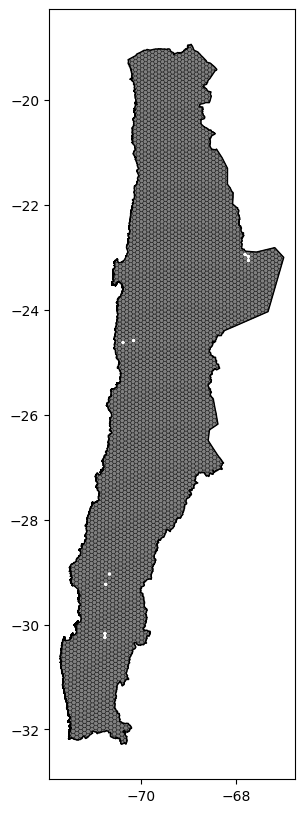

In [484]:
#Ploteamos el hexagonos
fig, ax = plt.subplots(figsize=(10, 10))
chile.boundary.plot(ax=ax, color='black', linewidth=1)
hexagonos.plot(ax=ax, color='gray', edgecolor='black', linewidth=0.3, label='Hexágonos sin observatorios')
plt.show()

# Desarrollo

### Predicción en base a la información de un vector ideal

Tomaremos la siguiente tabla con respecto a la información que poseemos de los telescopios:

| Requisito                  | Telescopio Óptico                 | Telescopio Radio                         |
| -------------------------- | --------------------------------- | ---------------------------------------- |
| **Nubosidad**              | Crítica (se necesita cielo claro) | No tan importante (puede observar nubes) |
| **Contaminación lumínica** | Crítica                           | Irrelevante                              |
| **Altitud**                | Deseable (menos atmósfera)        | No esencial                              |
| **Gases atmosféricos**     | Afecta la refracción (importa)    | Puede afectar bandas específicas         |
| **Ruido electromagnético** | No relevante                      | Muy relevante (Antenas)       |
| **Precipitación**          | Afecta ambas pero es tolerable    | Afecta instalaciones, pero menos         |


Por lo tanto separaremos cada uno de los hexagonos en base a lo antes mencionado, y crearemos un vector ideal para cada uno de los tipos de telescopios.

In [485]:
obs_opticos = obs_hex[obs_hex['Optico'] == 1]
obs_radio = obs_hex[obs_hex['Radio'] == 1]
obs_infrarrojo = obs_hex[obs_hex['Infrarrojo'] == 1]

In [519]:
#Vectores ideales para ópticos y radio (en base a los observatorios ya obtenidos)
vector_ideal_optico = obs_opticos[variables].mean()
vector_ideal_radio = obs_radio[variables].mean()
vector_ideal_infrarrojo = obs_infrarrojo[variables].mean()

In [517]:
print("vector_ideal_optico")
print(vector_ideal_optico)
print("\nvector_ideal_radio")
print(vector_ideal_radio)
print("\nvector_ideal_infrarrojo")
print(vector_ideal_infrarrojo)


vector_ideal_optico
calidad_aire1             0.542965
calidad_aire2             0.515479
calidad_aire3             0.266462
contaminacion_luminica    0.007786
elevacion                 0.411380
gases_atmosfericos        0.605311
nubosidad1                0.704825
nubosidad2                0.367392
precipitacion             0.076837
tipo_suelo                0.697143
dtype: float64

vector_ideal_radio
calidad_aire1             0.473767
calidad_aire2             0.449598
calidad_aire3             0.210773
contaminacion_luminica    0.002212
elevacion                 0.500515
gases_atmosfericos        0.602267
nubosidad1                0.819812
nubosidad2                0.406878
precipitacion             0.071135
tipo_suelo                0.707352
dtype: float64

vector_ideal_infrarrojo
calidad_aire1             0.561853
calidad_aire2             0.533539
calidad_aire3             0.220879
contaminacion_luminica    0.014304
elevacion                 0.430889
gases_atmosfericos        0.64

In [487]:
hex_norm = hexagonos.copy()
# Distancia a condiciones ópticas
hex_norm['dist_optico'] = cdist(hex_norm[variables], [vector_ideal_optico], metric='euclidean')[:, 0]

# Distancia a condiciones de radio
hex_norm['dist_radio'] = cdist(hex_norm[variables], [vector_ideal_radio], metric='euclidean')[:, 0]

# Distancia a condiciones de infrarrojo
hex_norm['dist_infrarrojo'] = cdist(hex_norm[variables], [vector_ideal_infrarrojo], metric='euclidean')[:, 0]

In [488]:
#obtenemos la distancia a antenas
hex_norm['radio_score_final'] = hex_norm['dist_radio'] + (1 - hex_norm['distancia_antena'])
#Normalizamos las distancias
scaler_radio = MinMaxScaler()
hex_norm['radio_score_final'] = scaler_radio.fit_transform(hex_norm[['radio_score_final']])

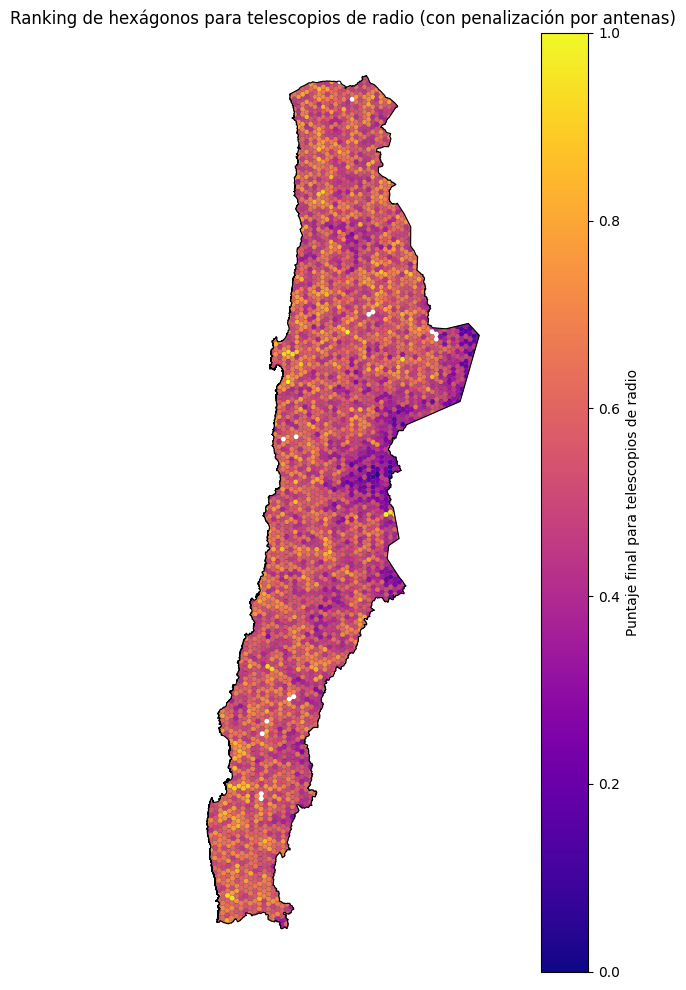

In [489]:
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

hex_norm.plot(
    column='radio_score_final',
    ax=ax,
    cmap='plasma',
    legend=True,
    legend_kwds={'label': "Puntaje final para telescopios de radio"},
    edgecolor='black',
    linewidth=0.1
)

chile.boundary.plot(ax=ax, color='black', linewidth=0.8)
ax.set_title("Ranking de hexágonos para telescopios de radio (con penalización por antenas)")
ax.axis('off')
plt.tight_layout()
plt.show()

In [490]:
top_optico = hex_norm.nsmallest(20, 'dist_optico')
top_radio = hex_norm.nsmallest(20, 'radio_score_final')
top_infrarrojo = hex_norm.nsmallest(20, 'dist_infrarrojo')

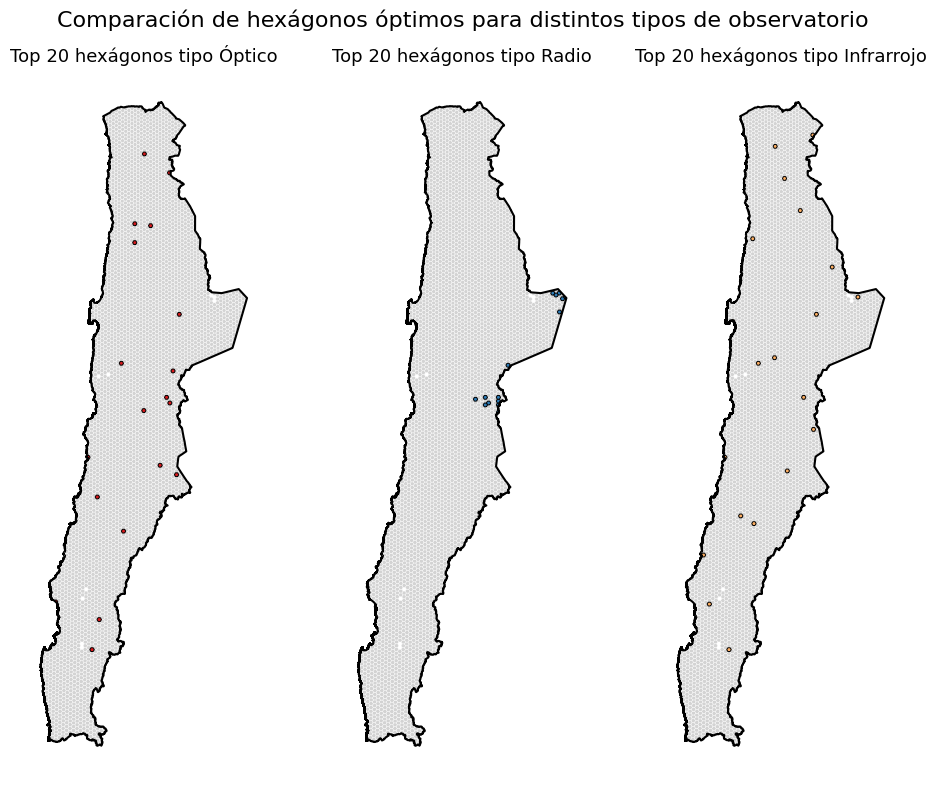

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(10, 8), sharex=True, sharey=True)


# Mapa óptico
chile.boundary.plot(ax=axes[0], color='black')
hexagonos.plot(ax=axes[0], color='lightgray', edgecolor='white', linewidth=0.3)
top_optico.plot(ax=axes[0], color='#D7191C', edgecolor='black', linewidth=0.7)
axes[0].set_title('Top 20 hexágonos tipo Óptico', fontsize=13)
axes[0].set_axis_off()

# Mapa radio
chile.boundary.plot(ax=axes[1], color='black')
hexagonos.plot(ax=axes[1], color='lightgray', edgecolor='white', linewidth=0.3)
top_radio.plot(ax=axes[1], color='#2C7BB6', edgecolor='black', linewidth=0.7)
axes[1].set_title('Top 20 hexágonos tipo Radio', fontsize=13)
axes[1].set_axis_off()

# Mapa infrarrojo
chile.boundary.plot(ax=axes[2], color='black')
hexagonos.plot(ax=axes[2], color='lightgray', edgecolor='white', linewidth=0.3)
top_infrarrojo.plot(ax=axes[2], color='#FDAE61', edgecolor='black', linewidth=0.7)
axes[2].set_title('Top 20 hexágonos tipo Infrarrojo', fontsize=13)
axes[2].set_axis_off()

# Título general
plt.suptitle("Comparación de hexágonos óptimos para distintos tipos de observatorio", fontsize=16)
plt.tight_layout()
#fig.savefig("mapa_observatorios_final.png", dpi=300, bbox_inches='tight')
plt.show()

In [492]:
prom_opt = top_optico[variables].mean()
prom_radio = top_radio[variables + ['distancia_antena']].mean()
prom_infr = top_infrarrojo[variables].mean()

print("Promedio de variables para hexágonos ópticos:")
print(prom_opt)
print("\nPromedio de variables para hexágonos de radio:")
print(prom_radio)
print("\nPromedio de variables para hexágonos infrarrojos:")
print(prom_infr)

Promedio de variables para hexágonos ópticos:
calidad_aire1             0.546858
calidad_aire2             0.519019
calidad_aire3             0.306104
contaminacion_luminica    0.001670
elevacion                 0.438249
gases_atmosfericos        0.604398
nubosidad1                0.702705
nubosidad2                0.296199
precipitacion             0.086483
tipo_suelo                0.693313
dtype: float64

Promedio de variables para hexágonos de radio:
calidad_aire1             0.473591
calidad_aire2             0.448894
calidad_aire3             0.170867
contaminacion_luminica    0.002367
elevacion                 0.467483
gases_atmosfericos        0.601019
nubosidad1                0.878490
nubosidad2                0.379168
precipitacion             0.034168
tipo_suelo                0.698879
distancia_antena          0.809582
dtype: float64

Promedio de variables para hexágonos infrarrojos:
calidad_aire1             0.556172
calidad_aire2             0.528223
calidad_aire3       

#### Estadisticas de los hexagonos ideales

In [493]:
top_radio[variables + ['distancia_antena']].describe()

,calidad_aire1,calidad_aire2,calidad_aire3,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,precipitacion,tipo_suelo,distancia_antena
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,0.473591,0.448894,0.170867,0.002367,0.467483,0.601019,0.878490,0.379168,0.034168,0.698879,0.809582
std,0.084833,0.081484,0.059391,0.002217,0.111184,0.055241,0.033446,0.126161,0.028234,0.033824,0.092231
min,0.325419,0.307201,0.077841,0.001334,0.291777,0.449934,0.794626,0.248405,0.007320,0.588651,0.670182
25%,0.434163,0.410773,0.119565,0.001672,0.379421,0.586716,0.858819,0.263232,0.012972,0.708184,0.726794
50%,0.474437,0.449810,0.188421,0.001785,0.468784,0.614556,0.876487,0.353128,0.027693,0.713764,0.826299
75%,0.513492,0.486912,0.208350,0.001957,0.571062,0.634650,0.893861,0.450398,0.043329,0.713764,0.873037
max,0.709967,0.676686,0.277010,0.011568,0.646724,0.676874,0.927717,0.690217,0.115639,0.714749,1.000000


In [494]:
top_optico[variables].describe()

,calidad_aire1,calidad_aire2,calidad_aire3,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,precipitacion,tipo_suelo
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,0.546858,0.519019,0.306104,0.001670,0.438249,0.604398,0.702705,0.296199,0.086483,0.693313
std,0.023286,0.022357,0.060401,0.000908,0.040662,0.025655,0.106534,0.022807,0.037919,0.040411
min,0.506917,0.480665,0.197428,0.001055,0.355159,0.549295,0.619195,0.270835,0.016143,0.591038
25%,0.533487,0.506171,0.264102,0.001190,0.405981,0.590356,0.627144,0.280764,0.039101,0.703002
50%,0.547287,0.519569,0.302393,0.001419,0.447567,0.609272,0.627144,0.280764,0.102262,0.713764
75%,0.560536,0.532381,0.360543,0.001601,0.467785,0.624430,0.842089,0.323667,0.112347,0.713764
max,0.590091,0.560316,0.387021,0.004740,0.489661,0.647452,0.849243,0.328013,0.134044,0.713764


In [495]:
top_infrarrojo[variables].describe()

,calidad_aire1,calidad_aire2,calidad_aire3,contaminacion_luminica,elevacion,gases_atmosfericos,nubosidad1,nubosidad2,precipitacion,tipo_suelo
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,2.000000e+01
mean,0.556172,0.528223,0.209236,0.001941,0.427768,0.642402,0.846347,0.315981,0.028230,7.137635e-01
std,0.027824,0.026758,0.034892,0.000312,0.047942,0.033638,0.013821,0.026136,0.009097,1.139065e-16
min,0.507453,0.481166,0.157084,0.001422,0.360668,0.582996,0.800511,0.221794,0.012182,7.137635e-01
25%,0.539216,0.511955,0.190251,0.001771,0.383307,0.626616,0.842115,0.322273,0.020905,7.137635e-01
50%,0.548090,0.520456,0.201393,0.001999,0.432285,0.634814,0.849243,0.322273,0.029824,7.137635e-01
75%,0.577557,0.548792,0.227466,0.002164,0.464283,0.660832,0.849243,0.327852,0.035166,7.137635e-01
max,0.612584,0.582347,0.282901,0.002390,0.507165,0.722024,0.882695,0.328013,0.045984,7.137635e-01


### Indice de Moran

In [496]:
gdf = hexagonos.copy()

w = Queen.from_dataframe(gdf)
w.transform = 'r'

resultados = []

#Las variables ya estan definidas en la parte de normalizacion
for var in variables:
    # Asegura que no haya NaNs en la variable actual
    y = gdf[var].dropna().values
    gdf_valid = gdf.loc[gdf[var].notna()]
    w_valid = Queen.from_dataframe(gdf_valid)
    w_valid.transform = 'r'

    moran = Moran(y, w_valid)
    resultados.append({
        'variable': var,
        "Moran's I": round(moran.I, 4),
        "p-value": round(moran.p_sim, 4),
        "significativo": moran.p_sim < 0.05
    })

df_resultados = pd.DataFrame(resultados).sort_values("p-value")
print(df_resultados)

('WARNING: ', 1767, ' is an island (no neighbors)')
('WARNING: ', 1894, ' is an island (no neighbors)')
('WARNING: ', 1988, ' is an island (no neighbors)')
('WARNING: ', 2303, ' is an island (no neighbors)')
('WARNING: ', 3848, ' is an island (no neighbors)')
('WARNING: ', 4667, ' is an island (no neighbors)')
('WARNING: ', 4673, ' is an island (no neighbors)')
('WARNING: ', 4674, ' is an island (no neighbors)')
('WARNING: ', 1767, ' is an island (no neighbors)')
('WARNING: ', 1894, ' is an island (no neighbors)')
('WARNING: ', 1988, ' is an island (no neighbors)')
('WARNING: ', 2303, ' is an island (no neighbors)')
('WARNING: ', 3848, ' is an island (no neighbors)')
('WARNING: ', 4666, ' is an island (no neighbors)')
('WARNING: ', 4672, ' is an island (no neighbors)')
('WARNING: ', 4673, ' is an island (no neighbors)')
('WARNING: ', 1767, ' is an island (no neighbors)')
('WARNING: ', 1894, ' is an island (no neighbors)')
('WARNING: ', 1988, ' is an island (no neighbors)')
('WARNING: '

Ojo que hay muchas islas :o

| Variable            | Moran's I | p-valor | Interpretación                                     |
| ------------------- | --------- | ------- | -------------------------------------------------- |
| gases\_atmosfericos | 0.0478    | 0.001   | **Agrupamiento claro** de zonas similares en gases |
| precipitacion       | 0.0953    | 0.001   | Fuerte agrupamiento en cuanto a precipitación      |
| tipo\_suelo         | 0.0394    | 0.001   | Zonas similares en uso del suelo están cerca       |
| nubosidad1          | 0.0254    | 0.013   | Hay zonas cercanas con nubosidad similar           |

El **Índice de Moran global** mide si una variable está espacialmente agrupada o no.

- Si una variable no presenta autocorrelación espacial, no tiene sentido usar técnicas como clustering espacial o segmentación por cercanía.

- Sí tiene autocorrelación (como precipitación, tipo_suelo, gases_atmosféricos en este caso), entonces los valores similares están geográficamente cerca, y eso habilita el uso de técnicas como KMeans, HDBSCAN, LISA, etc.

Esto permite que nos enfoquemos en las variables que sí aportan valor espacialmente, y descartemos o tomemos en cuenta las que son puramente aleatorias en el espacio.

### LISA

In [ ]:
hex_lisa = hex_norm.dropna(subset=['radio_score_final']).copy()

w = libpysal.weights.contiguity.Queen.from_dataframe(hex_lisa)
w.transform = 'r'

('WARNING: ', 1765, ' is an island (no neighbors)')
('WARNING: ', 1892, ' is an island (no neighbors)')
('WARNING: ', 1986, ' is an island (no neighbors)')
('WARNING: ', 2301, ' is an island (no neighbors)')
('WARNING: ', 3844, ' is an island (no neighbors)')
('WARNING: ', 4660, ' is an island (no neighbors)')
('WARNING: ', 4661, ' is an island (no neighbors)')
('WARNING: ', 4667, ' is an island (no neighbors)')
('WARNING: ', 4668, ' is an island (no neighbors)')


In [ ]:
lisa = Moran_Local(hex_lisa['radio_score_final'], w)

hex_lisa['lisa_cluster'] = lisa.q  # Cuadrante (HH, LL, LH, HL)
hex_lisa['lisa_p'] = lisa.p_sim  # p-valor de significancia


| `lisa_cluster` | Tipo de patrón     | Descripción                                |
| -------------- | ------------------ | ------------------------------------------ |
| 1              | **Alto-Alto (HH)** | Zonas con valores altos, rodeadas de altos |
| 2              | **Bajo-Bajo (LL)** | Zonas con valores bajos, rodeadas de bajos |
| 3              | **Alto-Bajo (HL)** | Valor alto rodeado de bajos (outlier)      |
| 4              | **Bajo-Alto (LH)** | Valor bajo rodeado de altos (outlier)      |


In [ ]:
palette = {
    "Coldspot": "blue",
    "Hotspot": "red",
    "Outlier (Cold in Hot)": "#83cef4",  # celeste
    "Outlier (Hot in Cold)": "#e59696",  # rosa
    "Not Significant": "gainsboro"
}

In [ ]:
def clasificar_lisa(row):
    if row['lisa_p'] >= 0.05:
        return "Not Significant"
    elif row['lisa_cluster'] == 1:
        return "Hotspot"
    elif row['lisa_cluster'] == 2:
        return "Coldspot"
    elif row['lisa_cluster'] == 3:
        return "Outlier (Hot in Cold)"
    elif row['lisa_cluster'] == 4:
        return "Outlier (Cold in Hot)"
    else:
        return "Not Significant"

hex_lisa['lisa_label'] = hex_lisa.apply(clasificar_lisa, axis=1)

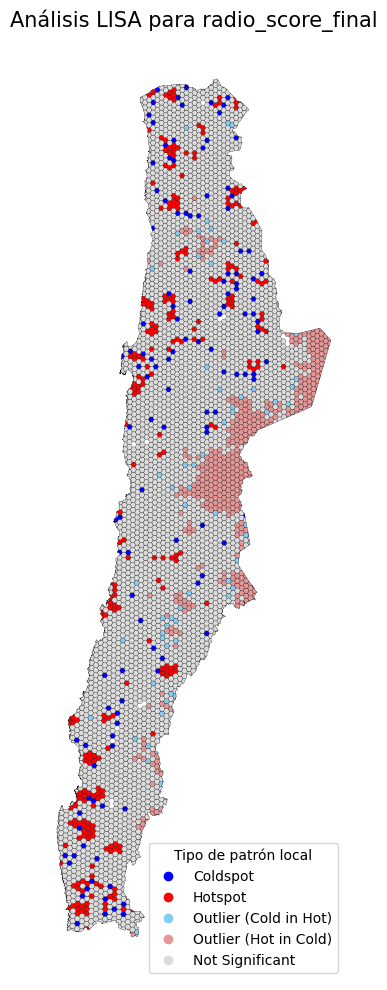

In [ ]:
fig, ax = plt.subplots(1, figsize=(10, 10))
legend_elements = []

for label, color in palette.items():
    subset = hex_lisa[hex_lisa["lisa_label"] == label]
    if not subset.empty:
        subset.plot(ax=ax, color=color, label=label, edgecolor="black", linewidth=0.2)
        legend_elements.append(
            plt.Line2D([0], [0], marker='o', color='w',
                    label=label, markerfacecolor=color, markersize=8)
        )

ax.set_title("Análisis LISA para radio_score_final", fontsize=15)
ax.legend(handles=legend_elements, title="Tipo de patrón local", loc='lower right')
ax.set_axis_off()
plt.tight_layout()
plt.show()


El Moran Local **(LISA)** detecta dónde están los grupos estadísticamente significativos. En este caso:
- Identifica zonas “favorables” o “desfavorables”

- Por ejemplo, zonas con bajo nivel de gases atmosféricos rodeadas de otras zonas similares (Low-Low) -> ideales para astronomía óptica.

- O zonas de alta contaminación atmosférica rodeadas de otras similares (High-High) -> zonas que deberías descartar completamente.

*No es lo mismo que haya un buen hexágono aislado a que haya una zona entera de condiciones favorables.*

### Kmeans

In [497]:
def plot_elbow_method(top):
    coords = np.array([(geom.centroid.x, geom.centroid.y) for geom in top.geometry])
    # Usamos coordenadas de los centroides de los hexágonos top (ej. tipo radio)
    # Evaluar k entre 1 y 10
    inertias = []

    K = range(1, 11)
    for k in K:
        kmeans = KMeans(n_clusters=k, random_state=42).fit(coords)
        inertias.append(kmeans.inertia_)
    # Graficar
    plt.figure(figsize=(8,5))

    plt.plot(K, inertias, 'bo-')
    plt.xlabel('Número de clusters (k)')
    plt.ylabel('Inercia (SSE)')
    plt.title('Método del Codo para determinar k')
    plt.grid(True)
    plt.show()
    return coords

In [498]:
def clusters_silhouette(coords):
    sil_scores = []
    for k in range(2, 11):
        kmeans = KMeans(n_clusters=k, random_state=42).fit(coords)
        labels = kmeans.labels_
        sil_scores.append(silhouette_score(coords, labels))


    #Printeamos el numero de clusters con mayor silhouette score
    best_k = np.argmax(sil_scores) + 2  # +2 porque empezamos en 2
    print(f"El mejor número de clusters (k) es: {best_k} con un Silhouette Score de {max(sil_scores):.4f}")
    # Graficar
    plt.figure(figsize=(8,5))
    plt.plot(range(2,11), sil_scores, 'go-')
    plt.xlabel('Número de clusters (k)')
    plt.ylabel('Silhouette Score')
    plt.title('Silhouette para distintos k')
    plt.grid(True)
    plt.show()

In [499]:
variables_moran = ['gases_atmosfericos', 'precipitacion', 'tipo_suelo', 'nubosidad1']

In [500]:
hex_no_nan_moran = hex_norm.dropna(subset=variables_moran)

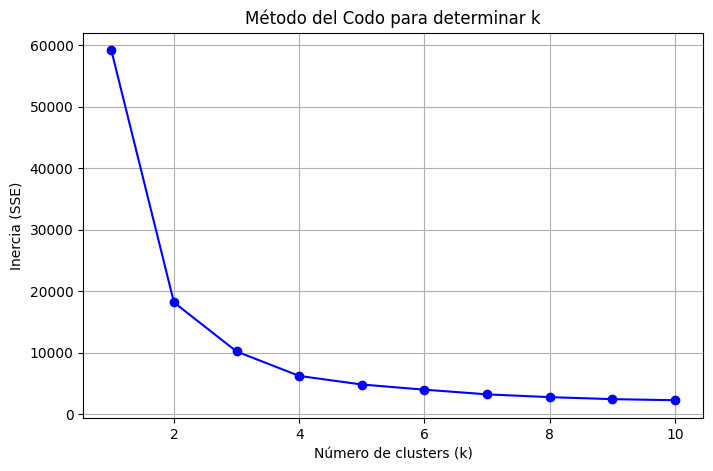

array([[-71.35795792, -32.19478021],
       [-70.40500547, -32.23923607],
       [-70.33760141, -32.25634178],
       ...,
       [-69.03324354, -19.01651612],
       [-68.97809545, -18.96999079],
       [-68.92772565, -19.00328702]])

In [501]:
plot_elbow_method(hex_no_nan_moran)

In [502]:
kmeans_moran = KMeans(n_clusters=3, random_state=42)
kmeans_moran.fit(hex_no_nan_moran[variables_moran])

KMeans(n_clusters=3, random_state=42)

In [503]:
top_radio['cluster'] = kmeans_moran.predict(top_radio[variables_moran])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


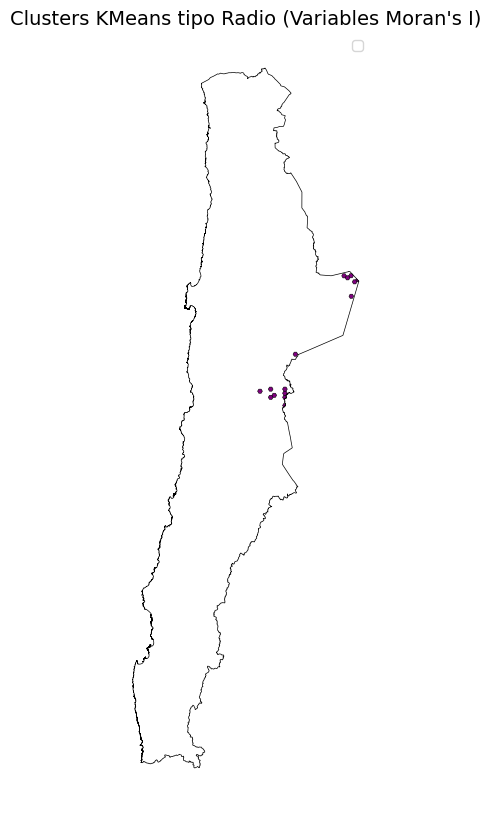

In [504]:
fig, ax = plt.subplots(1, figsize=(10, 10))
chile.boundary.plot(ax=ax, color='black', linewidth=0.5)

# Colores distintos por cluster (puedes ajustar según n_clusters)
colors = ['green', 'orange', 'purple']
for cluster_id in top_radio['cluster'].unique():
    subset = top_radio[top_radio['cluster'] == cluster_id]
    subset.plot(ax=ax, color=colors[cluster_id], label=f'Cluster {cluster_id}', edgecolor='black', linewidth=0.4)

# Opcional: agregar límites de Chile si tienes el shapefile
# chile.boundary.plot(ax=ax, color='black', linewidth=0.8)

plt.title("Clusters KMeans tipo Radio (Variables Moran's I)", fontsize=14)
plt.axis('off')
plt.legend()
plt.show()


### Random Forest

In [510]:
ids_obs_hex = obs_hex["id"].unique()
hexagonos_rf = hexagonos_totales.copy()
hexagonos_rf['objetivo'] = 0
hexagonos_rf.loc[hexagonos_totales["id"].isin(ids_obs_hex), 'objetivo'] = 1

X = hexagonos_rf[variables]
y = hexagonos_rf['objetivo']

print(y.value_counts())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)
print("Reporte de clasificación:\n", classification_report(y_test, y_pred))
print("Matriz de confusión:\n", confusion_matrix(y_test, y_pred))

objetivo
0    4720
1      29
Name: count, dtype: int64
Reporte de clasificación:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      1416
           1       0.00      0.00      0.00         9

    accuracy                           0.99      1425
   macro avg       0.50      0.50      0.50      1425
weighted avg       0.99      0.99      0.99      1425

Matriz de confusión:
 [[1416    0]
 [   9    0]]


El problema principal que tenemos con random Forest esque no poseemos un buen dataset de entrenamiento, por lo que no podemos entrenar un modelo de machine learning para predecir los hexagonos ideales.

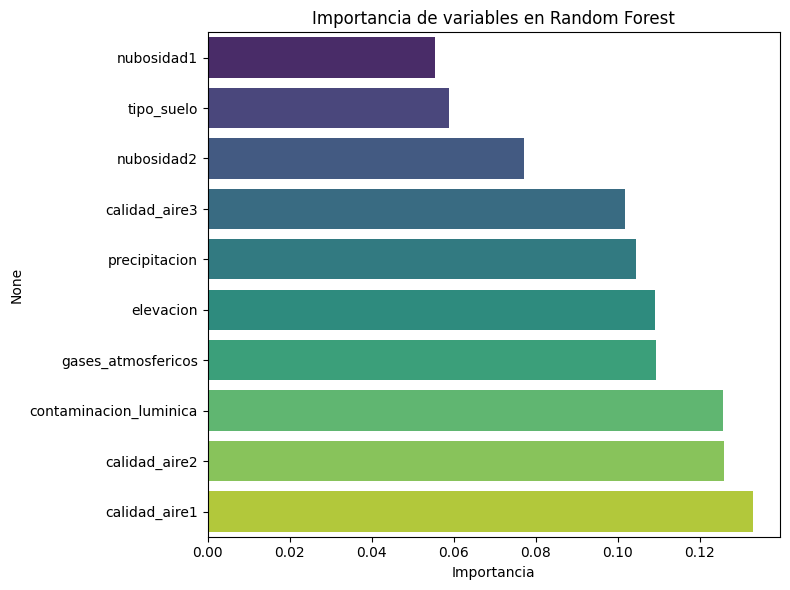

In [511]:

importancias = pd.Series(rf.feature_importances_, index=variables).sort_values(ascending=True)

plt.figure(figsize=(8,6))
sns.barplot(x=importancias, y=importancias.index, palette='viridis')
plt.title("Importancia de variables en Random Forest")
plt.xlabel("Importancia")
plt.tight_layout()
plt.show()


In [522]:
hexagonos_rf['prob_optimo'] = rf.predict_proba(X)[:, 1]
top_rf = hexagonos_rf.sort_values(by='prob_optimo', ascending=False).head(10)

## Conclusiones

Vimos como el procesamiento de los datos geoespaciales es un proceso complejo, que requiere de una gran cantidad de datos y de un buen conocimiento de las herramientas disponibles. En este proyecto, logramos desarrollar bastante la idea pero nos encontramos con limitaciones al momoento de definir la calidad de os hexagonos, especialmente al no poseer un buen dataset de entrenamiento para poder entrenar un modelo de machine learning que nos permita predecir los hexagonos ideales. Tambien un factor importante es que tal vez no todos los datos que elegimos son relevantes, por lo tanto teminamos gastando nuestro tiempo de forma ineficiente y no logramos llegar a algun resultadon que nosotros esperabamos.